In [10]:
import pandas as pd
import numpy as np
from prophet import Prophet
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

In [11]:
# load demand features and sort by date
df = pd.read_parquet(r"../data/features/demand_features.parquet")
df = df.sort_values("date").reset_index(drop=True)
df.head()

,date,demand,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_30,rolling_std_7,day_of_week,month,week_of_year,is_weekend
0,2010-01-13,6558,20823.0,11313.0,15207.0,15845.285714,17766.133333,11916.521426,2,1,2,0
1,2010-01-14,11899,6558.0,7471.0,15268.0,16477.857143,17348.200000,11508.434449,3,1,2,0
2,2010-01-15,8429,11899.0,40611.0,6254.0,11880.428571,16636.800000,4638.344743,4,1,2,0
3,2010-01-17,10040,8429.0,12702.0,8452.0,11500.142857,15370.433333,4668.785153,6,1,2,1
4,2010-01-18,8361,10040.0,13337.0,11916.0,10789.285714,14980.166667,4721.021737,0,1,3,0


In [12]:
# train Prophet model and generate 30-day future forecast
df_p = df.rename(columns={"date": "ds", "demand": "y"})
model_p = Prophet()
model_p.fit(df_p)
future = model_p.make_future_dataframe(periods=30)
forecast = model_p.predict(future)
prophet_preds = forecast.tail(30)["yhat"].values

03:14:52 - cmdstanpy - INFO - Chain [1] start processing
03:14:52 - cmdstanpy - INFO - Chain [1] done processing


In [13]:
# create lag features — previous 1, 2, 3, 7 days demand
df['lag_1'] = df['demand'].shift(1)
df['lag_2'] = df['demand'].shift(2)
df['lag_3'] = df['demand'].shift(3)
df['lag_7'] = df['demand'].shift(7)

# rolling average features over 3 and 7 days
df['rolling_mean_3'] = df['demand'].rolling(3).mean()
df['rolling_mean_7'] = df['demand'].rolling(7).mean()

# demand change from previous day
df['demand_diff'] = df['demand'] - df['demand'].shift(1)

# date-based features
df['day_of_week'] = pd.to_datetime(df['date']).dt.dayofweek
df['month'] = pd.to_datetime(df['date']).dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

df.dropna(inplace=True)

In [14]:
# select feature columns and prepare X and y arrays
feature_cols = [
    'lag_1', 'lag_2', 'lag_3', 'lag_7',
    'rolling_mean_3', 'rolling_mean_7',
    'demand_diff',
    'day_of_week', 'month', 'is_weekend'
]
X = df[feature_cols].values
y = df['demand'].values

In [15]:
# train/test split — 85% train, 15% test
n = len(X)

X_train = X[:int(n*0.85)]
y_train = y[:int(n*0.85)]

X_test = X[int(n*0.85):]
y_test = y[int(n*0.85):]

In [16]:
# train XGBoost model
model_xgb = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05
)
model_xgb.fit(X_train, y_train)

xgb_preds = model_xgb.predict(X_test)

In [17]:
# align lengths of both model predictions with actuals
min_len = min(len(prophet_preds), len(xgb_preds), len(y_test))

prophet_preds = prophet_preds[-min_len:]
xgb_preds = xgb_preds[-min_len:]
actuals = y_test[-min_len:]

# ensemble: 5% Prophet + 95% XGBoost
final_preds = 0.05 * prophet_preds + 0.95 * xgb_preds

# calculate MAPE
mape = np.mean(np.abs((actuals - final_preds) / actuals)) * 100

print("ENSEMBLE MAPE:", mape)

ENSEMBLE MAPE: 7.630888151451522


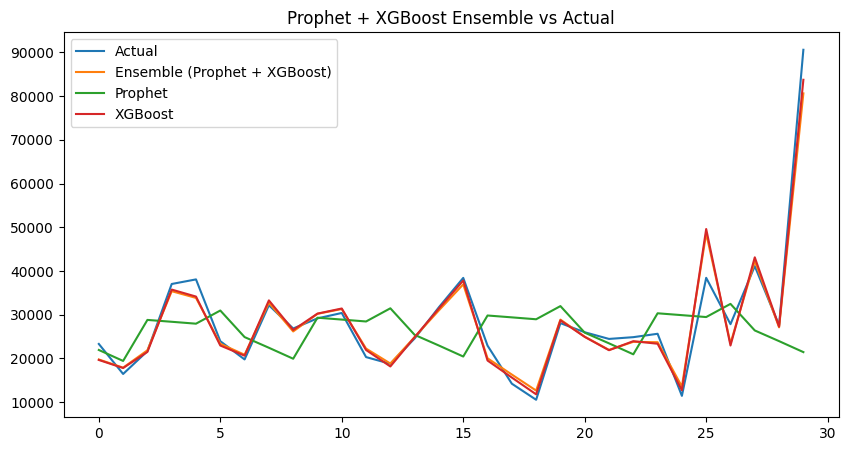

In [18]:
# plot actual vs ensemble and individual model predictions
plt.figure(figsize=(10, 5))

plt.plot(actuals, label="Actual")
plt.plot(final_preds, label="Ensemble (Prophet + XGBoost)")
plt.plot(prophet_preds, label="Prophet")
plt.plot(xgb_preds, label="XGBoost")

plt.legend()
plt.title("Prophet + XGBoost Ensemble vs Actual")

plt.show()